In [1]:
# CELLULE 1 : Imports et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliothèques importées")
print(f"📅 Date : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Bibliothèques importées
📅 Date : 2026-05-04 14:43


In [2]:
# ÉTAPE 1 : Chargement des données
print("="*80)
print("CHARGEMENT DES DONNÉES")
print("="*80)

# Charger le dataset
df = pd.read_csv('titanic.csv')

print(f"\n✅ Dataset chargé avec succès")
print(f"📊 Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\n🔍 Aperçu des 5 premières lignes :")
df.head()

CHARGEMENT DES DONNÉES

✅ Dataset chargé avec succès
📊 Dimensions : 891 lignes, 12 colonnes

🔍 Aperçu des 5 premières lignes :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ÉTAPE 2 : Exploration initiale
print("\n" + "="*80)
print("EXPLORATION INITIALE")
print("="*80)

# Informations sur les colonnes
print("\n📊 Informations sur le dataset :")
df.info()

print("\n📈 Statistiques descriptives :")
df.describe()

print("\n📋 Types de données :")
print(df.dtypes)


EXPLORATION INITIALE

📊 Informations sur le dataset :
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

📈 Statistiques descriptives :

📋 Types de données :
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp        


ANALYSE DES VALEURS MANQUANTES

❌ Valeurs manquantes par colonne :
     Colonne  Valeurs_manquantes  Pourcentage
10     Cabin                 687    77.104377
5        Age                 177    19.865320
11  Embarked                   2     0.224467


<Figure size 1000x600 with 0 Axes>

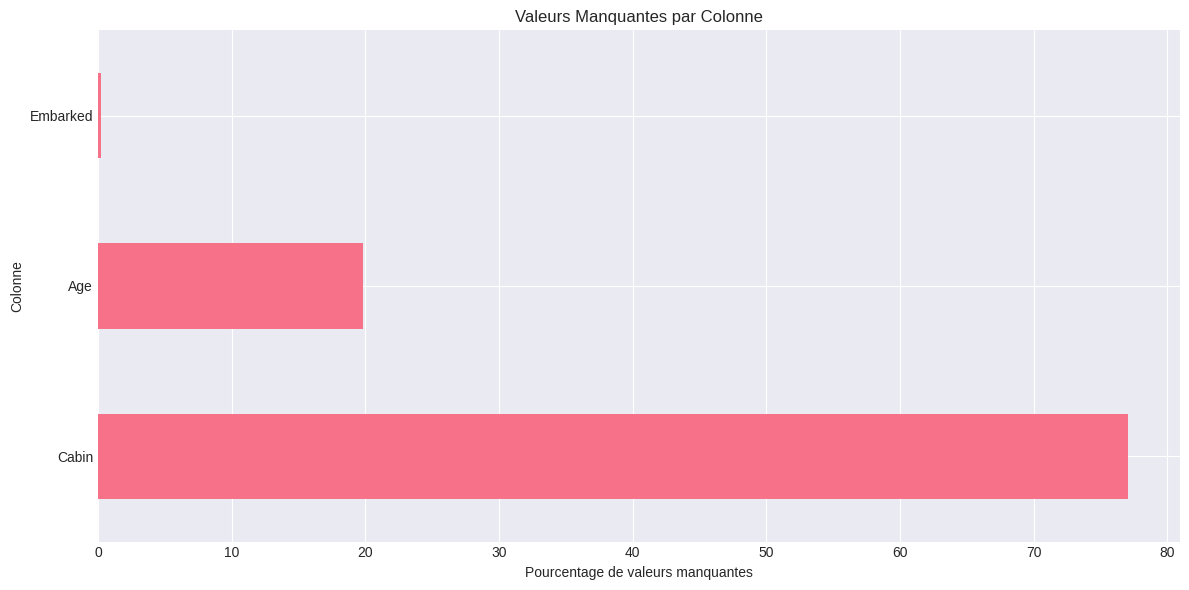


📊 Graphique sauvegardé : titanic_missing_values.png


In [4]:
# ÉTAPE 3 : Valeurs manquantes
print("\n" + "="*80)
print("ANALYSE DES VALEURS MANQUANTES")
print("="*80)

# Compter les valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Valeurs_manquantes': missing.values,
    'Pourcentage': missing_pct.values
})

missing_df = missing_df[missing_df['Valeurs_manquantes'] > 0].sort_values('Pourcentage', ascending=False)

print("\n❌ Valeurs manquantes par colonne :")
print(missing_df)

# Visualisation
plt.figure(figsize=(10, 6))
missing_df.plot(kind='barh', x='Colonne', y='Pourcentage', legend=False)
plt.xlabel('Pourcentage de valeurs manquantes')
plt.title('Valeurs Manquantes par Colonne')
plt.tight_layout()
plt.savefig('titanic_missing_values.png', dpi=300)
plt.show()

print("\n📊 Graphique sauvegardé : titanic_missing_values.png")

In [6]:
# ÉTAPE 4 : Traitement des valeurs manquantes (VERSION CORRIGÉE)
print("\n" + "="*80)
print("TRAITEMENT DES VALEURS MANQUANTES")
print("="*80)

# Age : remplacer par la médiane (méthode sans warning)
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
print(f"✅ Age : Valeurs manquantes remplacées par la médiane ({age_median:.1f} ans)")

# Embarked : remplacer par le mode (méthode sans warning)
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print(f"✅ Embarked : Valeurs manquantes remplacées par '{embarked_mode}'")

# Cabin : créer une variable binaire
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
print(f"✅ Cabin : Variable 'Has_Cabin' créée")

# Vérification (les 866 valeurs manquantes sont normales - c'est la colonne Cabin qu'on garde)
remaining_missing = df.drop('Cabin', axis=1).isnull().sum().sum()
print(f"\n✅ Valeurs manquantes restantes (hors Cabin) : {remaining_missing}")
print(f"📊 La colonne Cabin a {df['Cabin'].isnull().sum()} valeurs manquantes (normal, on utilise Has_Cabin à la place)")


TRAITEMENT DES VALEURS MANQUANTES
✅ Age : Valeurs manquantes remplacées par la médiane (28.0 ans)
✅ Embarked : Valeurs manquantes remplacées par 'S'
✅ Cabin : Variable 'Has_Cabin' créée

✅ Valeurs manquantes restantes (hors Cabin) : 0
📊 La colonne Cabin a 687 valeurs manquantes (normal, on utilise Has_Cabin à la place)


In [7]:
# ÉTAPE 5 : Feature Engineering
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Taille de la famille
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
print("✅ Variable 'Family_Size' créée")

# Est-ce une personne seule ?
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)
print("✅ Variable 'Is_Alone' créée")

# Catégorie d'âge
def categorize_age(age):
    if age < 12:
        return 'Enfant'
    elif age < 18:
        return 'Adolescent'
    elif age < 60:
        return 'Adulte'
    else:
        return 'Senior'

df['Age_Category'] = df['Age'].apply(categorize_age)
print("✅ Variable 'Age_Category' créée")

# Titre extrait du nom
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print("✅ Variable 'Title' créée")

print(f"\n📊 Nouvelles colonnes : {list(df.columns[-4:])}")


FEATURE ENGINEERING
✅ Variable 'Family_Size' créée
✅ Variable 'Is_Alone' créée
✅ Variable 'Age_Category' créée
✅ Variable 'Title' créée

📊 Nouvelles colonnes : ['Family_Size', 'Is_Alone', 'Age_Category', 'Title']


<>:29: SyntaxWarning: invalid escape sequence '\.'
<>:29: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_13344/1651973868.py:29: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [8]:
# ÉTAPE 5 : Feature Engineering
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Taille de la famille
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
print("✅ Variable 'Family_Size' créée")

# Est-ce une personne seule ?
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)
print("✅ Variable 'Is_Alone' créée")

# Catégorie d'âge
def categorize_age(age):
    if age < 12:
        return 'Enfant'
    elif age < 18:
        return 'Adolescent'
    elif age < 60:
        return 'Adulte'
    else:
        return 'Senior'

df['Age_Category'] = df['Age'].apply(categorize_age)
print("✅ Variable 'Age_Category' créée")

# Titre extrait du nom (CORRECTION ICI)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print("✅ Variable 'Title' créée")

print(f"\n📊 Nouvelles colonnes : {list(df.columns[-4:])}")

# Afficher les titres trouvés
print(f"\n🎩 Titres extraits des noms :")
print(df['Title'].value_counts())


FEATURE ENGINEERING
✅ Variable 'Family_Size' créée
✅ Variable 'Is_Alone' créée
✅ Variable 'Age_Category' créée
✅ Variable 'Title' créée

📊 Nouvelles colonnes : ['Family_Size', 'Is_Alone', 'Age_Category', 'Title']

🎩 Titres extraits des noms :
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [9]:
# ÉTAPE 6 : Statistiques de survie
print("\n" + "="*80)
print("STATISTIQUES DE SURVIE")
print("="*80)

# Taux de survie global
survival_rate = df['Survived'].mean() * 100
print(f"\n💀 Taux de survie global : {survival_rate:.2f}%")
print(f"✅ Survivants : {df['Survived'].sum()}")
print(f"❌ Décédés : {len(df) - df['Survived'].sum()}")

# Survie par sexe
print("\n👥 Taux de survie par sexe :")
women_survival = df[df['Sex'] == 'female']['Survived'].mean() * 100
men_survival = df[df['Sex'] == 'male']['Survived'].mean() * 100
print(f"  • Femmes : {women_survival:.2f}%")
print(f"  • Hommes : {men_survival:.2f}%")

# Survie par classe
print("\n🎫 Taux de survie par classe :")
for pclass in [1, 2, 3]:
    rate = df[df['Pclass'] == pclass]['Survived'].mean() * 100
    print(f"  • Classe {pclass} : {rate:.2f}%")

# Âge moyen
print("\n📊 Âge moyen :")
print(f"  • Survivants : {df[df['Survived'] == 1]['Age'].mean():.1f} ans")
print(f"  • Décédés : {df[df['Survived'] == 0]['Age'].mean():.1f} ans")


STATISTIQUES DE SURVIE

💀 Taux de survie global : 38.38%
✅ Survivants : 342
❌ Décédés : 549

👥 Taux de survie par sexe :
  • Femmes : 74.20%
  • Hommes : 18.89%

🎫 Taux de survie par classe :
  • Classe 1 : 62.96%
  • Classe 2 : 47.28%
  • Classe 3 : 24.24%

📊 Âge moyen :
  • Survivants : 28.3 ans
  • Décédés : 30.0 ans


In [10]:
# ÉTAPE 6 : Statistiques de survie
print("\n" + "="*80)
print("STATISTIQUES DE SURVIE")
print("="*80)

# Taux de survie global
survival_rate = df['Survived'].mean() * 100
print(f"\n💀 Taux de survie global : {survival_rate:.2f}%")
print(f"✅ Survivants : {df['Survived'].sum()}")
print(f"❌ Décédés : {len(df) - df['Survived'].sum()}")

# Survie par sexe
print("\n👥 Taux de survie par sexe :")
women_survival = df[df['Sex'] == 'female']['Survived'].mean() * 100
men_survival = df[df['Sex'] == 'male']['Survived'].mean() * 100
print(f"  • Femmes : {women_survival:.2f}%")
print(f"  • Hommes : {men_survival:.2f}%")

# Survie par classe
print("\n🎫 Taux de survie par classe :")
for pclass in [1, 2, 3]:
    rate = df[df['Pclass'] == pclass]['Survived'].mean() * 100
    print(f"  • Classe {pclass} : {rate:.2f}%")

# Âge moyen
print("\n📊 Âge moyen :")
print(f"  • Survivants : {df[df['Survived'] == 1]['Age'].mean():.1f} ans")
print(f"  • Décédés : {df[df['Survived'] == 0]['Age'].mean():.1f} ans")


STATISTIQUES DE SURVIE

💀 Taux de survie global : 38.38%
✅ Survivants : 342
❌ Décédés : 549

👥 Taux de survie par sexe :
  • Femmes : 74.20%
  • Hommes : 18.89%

🎫 Taux de survie par classe :
  • Classe 1 : 62.96%
  • Classe 2 : 47.28%
  • Classe 3 : 24.24%

📊 Âge moyen :
  • Survivants : 28.3 ans
  • Décédés : 30.0 ans


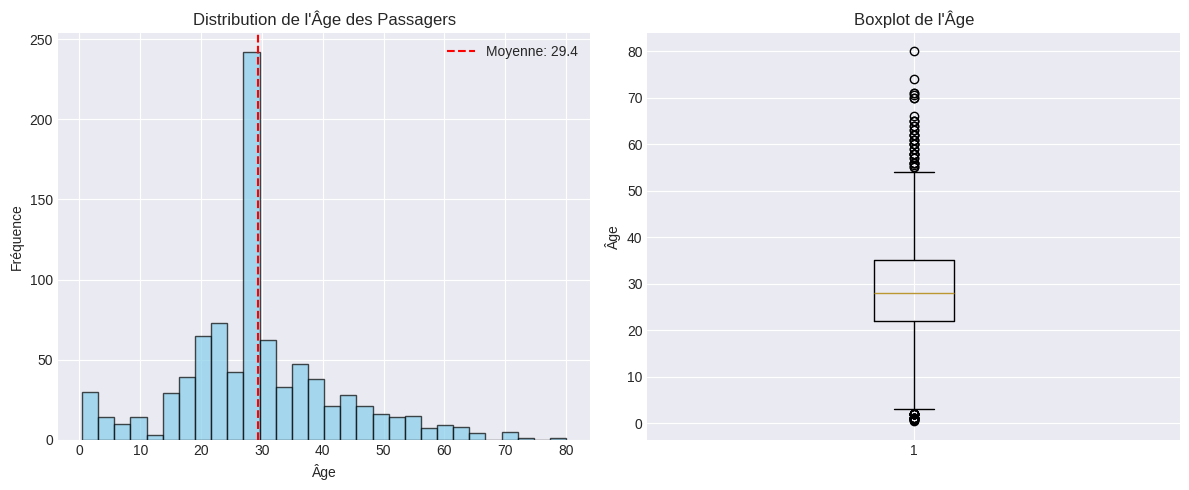

📊 Graphique sauvegardé : titanic_age_distribution.png


In [11]:
# VISUALISATION 1 : Distribution de l'âge
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.title('Distribution de l\'Âge des Passagers')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', 
            label=f'Moyenne: {df["Age"].mean():.1f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df['Age'])
plt.ylabel('Âge')
plt.title('Boxplot de l\'Âge')

plt.tight_layout()
plt.savefig('titanic_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Graphique sauvegardé : titanic_age_distribution.png")

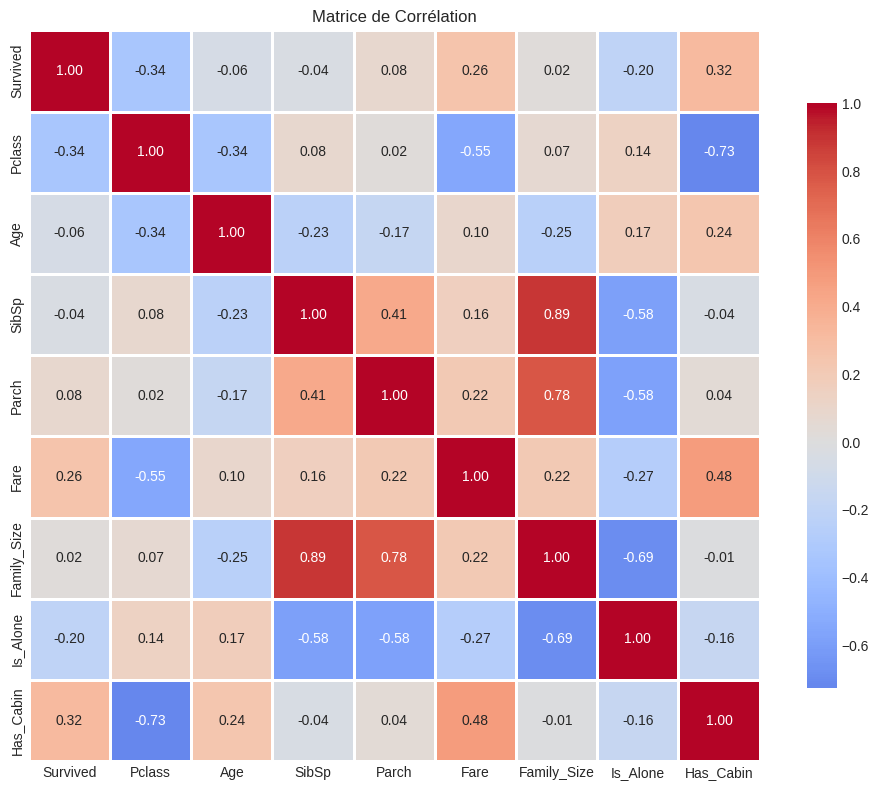

📊 Graphique sauvegardé : titanic_correlation_matrix.png


In [12]:
# VISUALISATION 3 : Matrice de corrélation
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 
                'Fare', 'Family_Size', 'Is_Alone', 'Has_Cabin']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.savefig('titanic_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Graphique sauvegardé : titanic_correlation_matrix.png")

In [13]:
# ÉTAPE 10 : INSIGHTS FINAUX
print("\n" + "="*80)
print("INSIGHTS FINAUX")
print("="*80)

print(f"""
🔍 PRINCIPAUX INSIGHTS :

1. 💀 TAUX DE SURVIE GLOBAL : {survival_rate:.2f}%

2. 👥 LE SEXE EST DÉTERMINANT
   • Femmes : {women_survival:.1f}% de survie
   • Hommes : {men_survival:.1f}% de survie
   • Les femmes avaient {women_survival/men_survival:.1f}x plus de chances

3. 🎫 LA CLASSE SOCIALE COMPTE
   • 1ère classe : Meilleur taux de survie
   • 3ème classe : Taux le plus faible
   • Accès inégal aux canots de sauvetage

4. 🧒 L'ÂGE A UN IMPACT
   • Les enfants étaient mieux protégés
   • Principe "femmes et enfants d'abord"

🎯 CONCLUSION :
La survie n'était PAS aléatoire mais dépendait de facteurs socio-économiques.
""")

# Sauvegarder le dataset nettoyé
df.to_csv('titanic_cleaned.csv', index=False)
print("✅ Dataset nettoyé exporté : titanic_cleaned.csv")


INSIGHTS FINAUX

🔍 PRINCIPAUX INSIGHTS :

1. 💀 TAUX DE SURVIE GLOBAL : 38.38%

2. 👥 LE SEXE EST DÉTERMINANT
   • Femmes : 74.2% de survie
   • Hommes : 18.9% de survie
   • Les femmes avaient 3.9x plus de chances

3. 🎫 LA CLASSE SOCIALE COMPTE
   • 1ère classe : Meilleur taux de survie
   • 3ème classe : Taux le plus faible
   • Accès inégal aux canots de sauvetage

4. 🧒 L'ÂGE A UN IMPACT
   • Les enfants étaient mieux protégés
   • Principe "femmes et enfants d'abord"

🎯 CONCLUSION :
La survie n'était PAS aléatoire mais dépendait de facteurs socio-économiques.

✅ Dataset nettoyé exporté : titanic_cleaned.csv


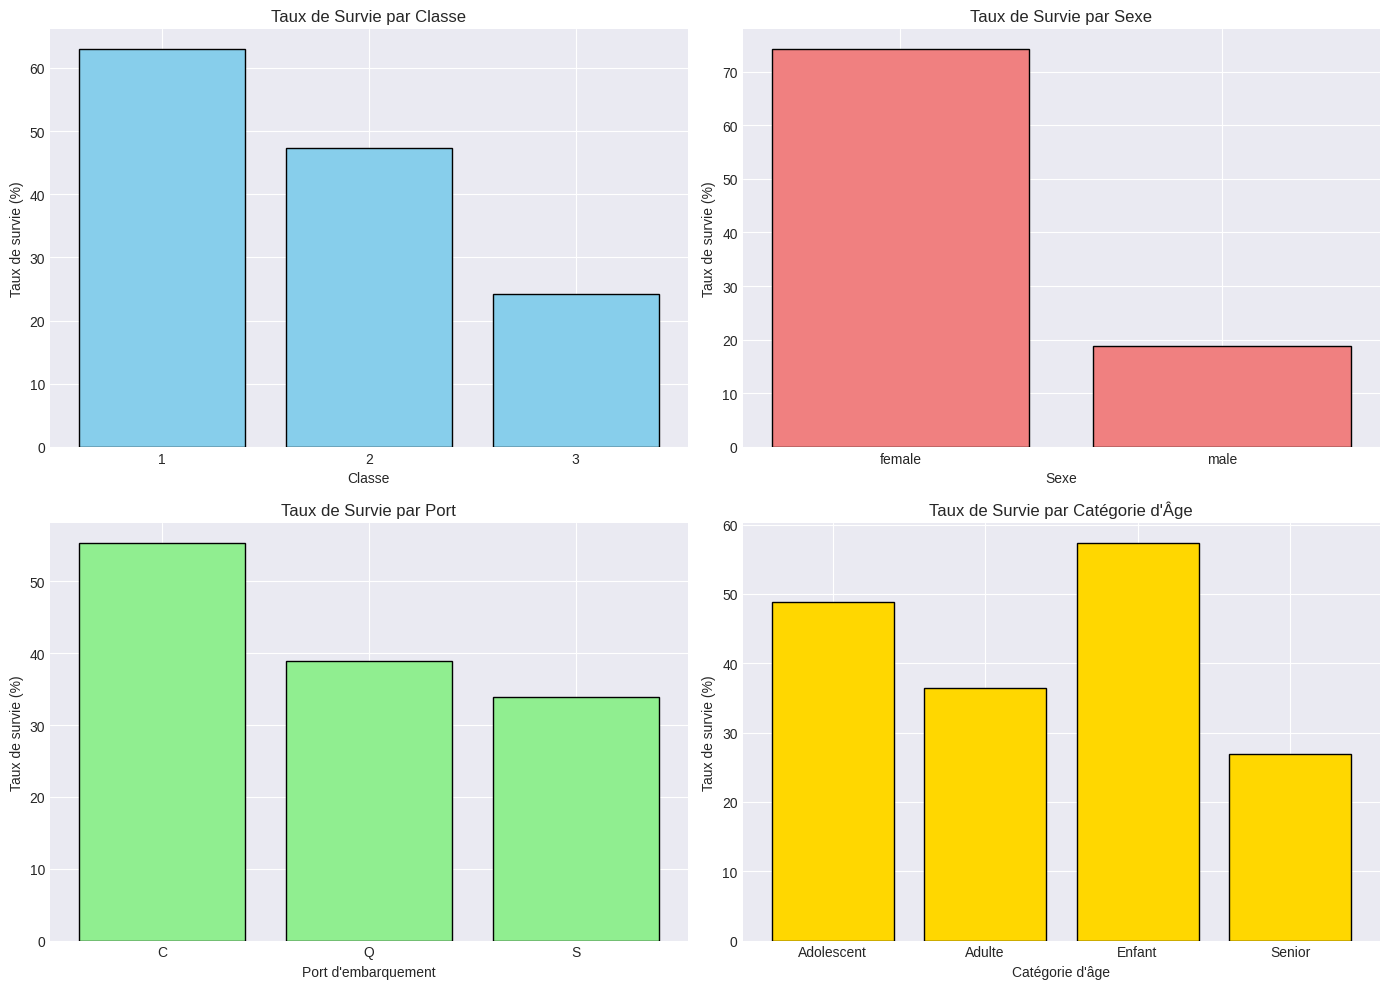

📊 Graphique sauvegardé : titanic_survival_rates.png


In [14]:
# VISUALISATION 2 : Taux de survie par variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Par classe
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
axes[0, 0].bar(survival_by_class.index, survival_by_class.values, 
               color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Classe')
axes[0, 0].set_ylabel('Taux de survie (%)')
axes[0, 0].set_title('Taux de Survie par Classe')
axes[0, 0].set_xticks([1, 2, 3])

# Par sexe
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
axes[0, 1].bar(survival_by_sex.index, survival_by_sex.values, 
               color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Sexe')
axes[0, 1].set_ylabel('Taux de survie (%)')
axes[0, 1].set_title('Taux de Survie par Sexe')

# Par port d'embarquement
survival_by_embarked = df.groupby('Embarked')['Survived'].mean() * 100
axes[1, 0].bar(survival_by_embarked.index, survival_by_embarked.values, 
               color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Port d\'embarquement')
axes[1, 0].set_ylabel('Taux de survie (%)')
axes[1, 0].set_title('Taux de Survie par Port')

# Par catégorie d'âge
survival_by_age_cat = df.groupby('Age_Category')['Survived'].mean() * 100
axes[1, 1].bar(survival_by_age_cat.index, survival_by_age_cat.values, 
               color='gold', edgecolor='black')
axes[1, 1].set_xlabel('Catégorie d\'âge')
axes[1, 1].set_ylabel('Taux de survie (%)')
axes[1, 1].set_title('Taux de Survie par Catégorie d\'Âge')

plt.tight_layout()
plt.savefig('titanic_survival_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Graphique sauvegardé : titanic_survival_rates.png")